# Mass-Aware RoPE Evaluation

This notebook evaluates the current peak-set encoder architecture after migrating from Fourier stem features to **mass-aware RoPE** with optional complement heads.

It covers:
1. RoPE frequency band construction for precision 0.1 vs 0.01 Da
2. Geometric kernels for Δm heads vs complement-residual heads
3. Encoder output behavior across `no_rope`, `all_mass_heads`, and `split_complement_heads`
4. Embedded regression tests executed inside the notebook


In [1]:
import math
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.model import PeakSetSIGReg

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 140
torch.manual_seed(2026)
np.random.seed(2026)

out_dir = ROOT / 'notebooks'
out_dir.mkdir(parents=True, exist_ok=True)
print('Output directory:', out_dir.resolve())


Output directory: /home/wuhao/spectra-learning/notebooks


In [2]:
def build_model(*, use_rope: bool, rope_mz_precision: float = 0.1, rope_complement_heads: int | None = None):
    return PeakSetSIGReg(
        num_peaks=60,
        model_dim=64,
        encoder_num_layers=2,
        encoder_num_heads=4,
        encoder_num_kv_heads=2,
        attention_mlp_multiple=2.0,
        feature_mlp_hidden_dim=32,
        encoder_use_rope=use_rope,
        rope_mz_max=1000.0,
        rope_mz_precision=rope_mz_precision,
        rope_complement_heads=rope_complement_heads,
        rope_modulo_2pi=True,
        sigreg_use_projector=False,
        pooling_type='mean',
    ).eval()


def make_batch(batch_size: int = 16, num_peaks: int = 60):
    valid_count = num_peaks - 10
    peak_mz = torch.rand(batch_size, num_peaks)
    peak_intensity = torch.rand(batch_size, num_peaks)
    peak_valid_mask = torch.zeros(batch_size, num_peaks, dtype=torch.bool)
    peak_valid_mask[:, :valid_count] = True
    peak_mz[:, valid_count:] = 0.0
    peak_intensity[:, valid_count:] = 0.0
    precursor_mz = torch.rand(batch_size)
    return peak_mz, peak_intensity, peak_valid_mask, precursor_mz


def describe_precision(precision: float, head_dim: int = 64):
    k = head_dim // 2
    lambda_min = 2.0 * precision
    lambda_max = 1000.0
    lambdas = np.logspace(np.log10(lambda_min), np.log10(lambda_max), num=k)
    omega = (2.0 * np.pi) / lambdas
    return {
        'precision': precision,
        'lambda_min': float(lambdas[0]),
        'lambda_max': float(lambdas[-1]),
        'omega_max': float(omega[0]),
        'omega_min': float(omega[-1]),
        'lambdas': lambdas,
        'omega': omega,
    }


## 1) Frequency Bands: Precision 0.1 vs 0.01 Da

Precision 0.1 Da: {'precision': 0.1, 'lambda_min': 0.2, 'lambda_max': 1000.0, 'omega_max': 31.41592653589793, 'omega_min': 0.006283185307179587}
Precision 0.01 Da: {'precision': 0.01, 'lambda_min': 0.020000000000000004, 'lambda_max': 1000.0, 'omega_max': 314.15926535897927, 'omega_min': 0.006283185307179587}


Saved: /home/wuhao/spectra-learning/notebooks/mass_rope_frequency_bands.png


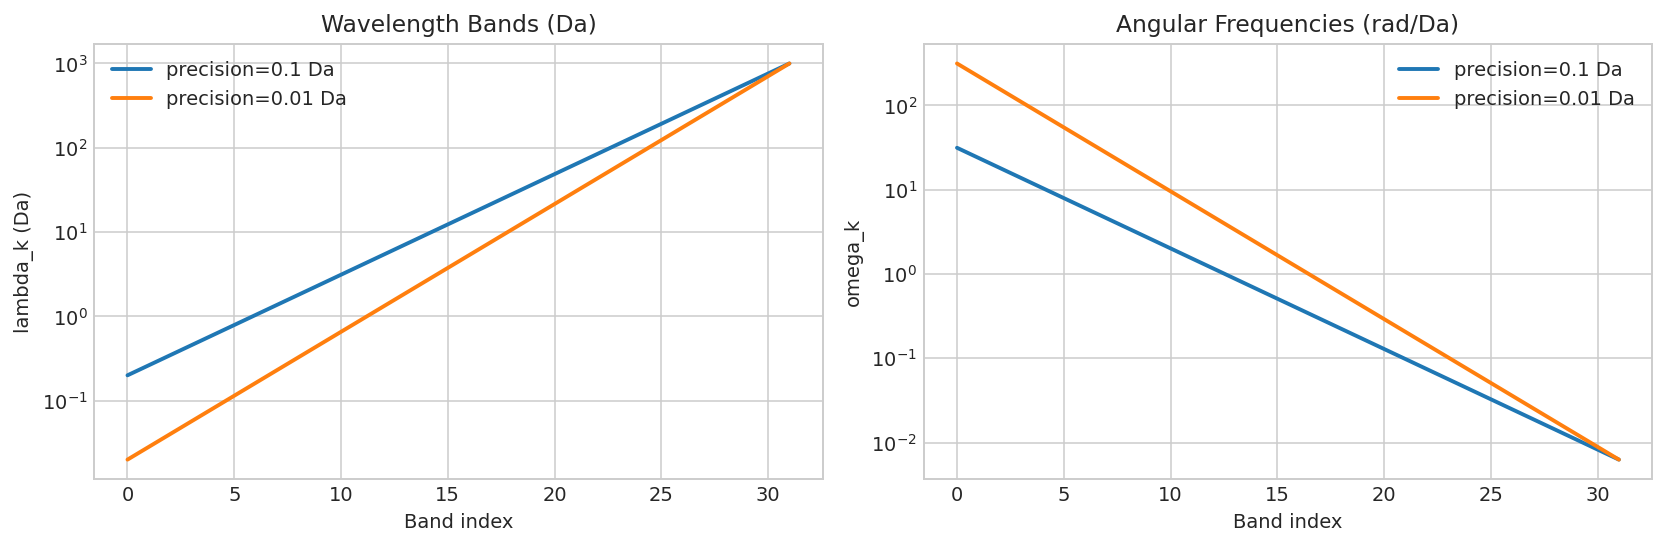

In [3]:
spec_01 = describe_precision(0.1)
spec_001 = describe_precision(0.01)

print('Precision 0.1 Da:', {k: v for k, v in spec_01.items() if not isinstance(v, np.ndarray)})
print('Precision 0.01 Da:', {k: v for k, v in spec_001.items() if not isinstance(v, np.ndarray)})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(spec_01['lambdas'], label='precision=0.1 Da', lw=2)
axes[0].plot(spec_001['lambdas'], label='precision=0.01 Da', lw=2)
axes[0].set_yscale('log')
axes[0].set_title('Wavelength Bands (Da)')
axes[0].set_xlabel('Band index')
axes[0].set_ylabel('lambda_k (Da)')
axes[0].legend()

axes[1].plot(spec_01['omega'], label='precision=0.1 Da', lw=2)
axes[1].plot(spec_001['omega'], label='precision=0.01 Da', lw=2)
axes[1].set_yscale('log')
axes[1].set_title('Angular Frequencies (rad/Da)')
axes[1].set_xlabel('Band index')
axes[1].set_ylabel('omega_k')
axes[1].legend()

fig.tight_layout()
fig_path = out_dir / 'mass_rope_frequency_bands.png'
fig.savefig(fig_path, bbox_inches='tight')
print('Saved:', fig_path)
plt.show()


## 2) Geometry Visualization: Δm Kernel vs Complement-Residual Kernel

/tmp/ipykernel_2433981/3987446257.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: /home/wuhao/spectra-learning/notebooks/mass_rope_geometry_kernels.png


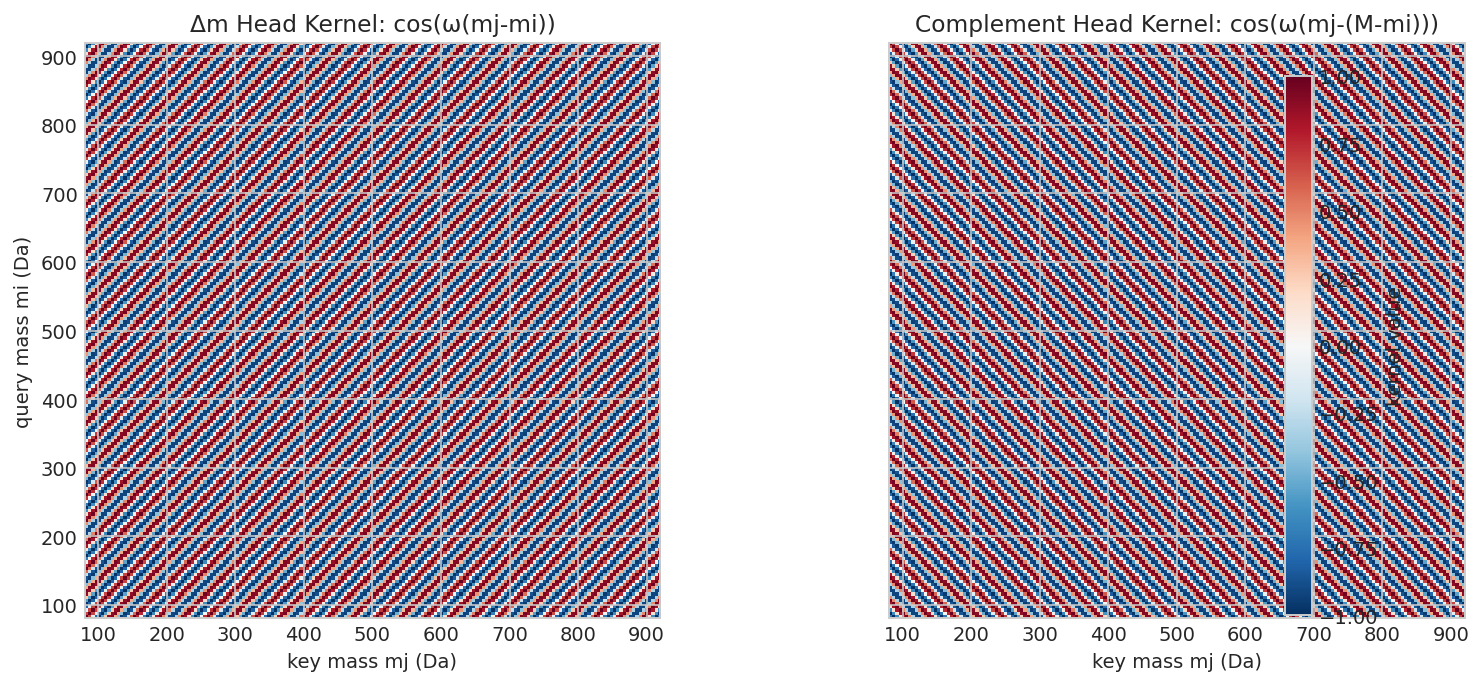

In [4]:
M = 1000.0
mass_axis = np.linspace(80.0, 920.0, 180)
mi = mass_axis[:, None]
mj = mass_axis[None, :]

# Use a mid-range band to visualize smooth but structured geometry.
omega = float(spec_01['omega'][12])

kernel_delta = np.cos(omega * (mj - mi))
kernel_comp = np.cos(omega * (mj - (M - mi)))  # == cos(omega * (mi + mj - M))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
im0 = axes[0].imshow(kernel_delta, cmap='RdBu_r', vmin=-1, vmax=1, origin='lower', extent=[mass_axis[0], mass_axis[-1], mass_axis[0], mass_axis[-1]])
axes[0].set_title('Δm Head Kernel: cos(ω(mj-mi))')
axes[0].set_xlabel('key mass mj (Da)')
axes[0].set_ylabel('query mass mi (Da)')

im1 = axes[1].imshow(kernel_comp, cmap='RdBu_r', vmin=-1, vmax=1, origin='lower', extent=[mass_axis[0], mass_axis[-1], mass_axis[0], mass_axis[-1]])
axes[1].set_title('Complement Head Kernel: cos(ω(mj-(M-mi)))')
axes[1].set_xlabel('key mass mj (Da)')

cbar = fig.colorbar(im1, ax=axes.ravel().tolist(), fraction=0.025)
cbar.set_label('kernel value')
fig.tight_layout()
fig_path = out_dir / 'mass_rope_geometry_kernels.png'
fig.savefig(fig_path, bbox_inches='tight')
print('Saved:', fig_path)
plt.show()


## 3) Encoder Behavior Across RoPE Variants

/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


{'mean_abs(no_rope, all_mass)': 0.07818380743265152, 'mean_abs(all_mass, split)': 0.06869124621152878, 'finite_no_rope': True, 'finite_all_mass': True, 'finite_split': True}
Saved: /home/wuhao/spectra-learning/notebooks/mass_rope_embedding_differences.png


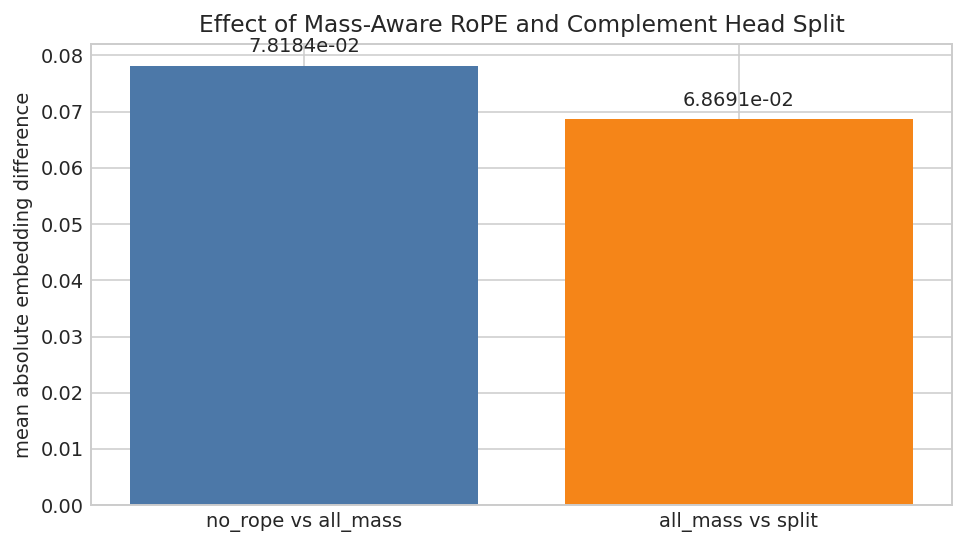

In [5]:
batch = make_batch(batch_size=24)
peak_mz, peak_intensity, peak_valid_mask, precursor_mz = batch

torch.manual_seed(1234)
model_no_rope = build_model(use_rope=False)
torch.manual_seed(1234)
model_all_mass = build_model(use_rope=True, rope_mz_precision=0.1, rope_complement_heads=0)
torch.manual_seed(1234)
model_split = build_model(use_rope=True, rope_mz_precision=0.1, rope_complement_heads=2)

with torch.no_grad():
    emb_no = model_no_rope.encoder(peak_mz, peak_intensity, valid_mask=peak_valid_mask, precursor_mz=precursor_mz)
    emb_mass = model_all_mass.encoder(peak_mz, peak_intensity, valid_mask=peak_valid_mask, precursor_mz=precursor_mz)
    emb_split = model_split.encoder(peak_mz, peak_intensity, valid_mask=peak_valid_mask, precursor_mz=precursor_mz)

metrics = {
    'mean_abs(no_rope, all_mass)': float((emb_no - emb_mass).abs().mean()),
    'mean_abs(all_mass, split)': float((emb_mass - emb_split).abs().mean()),
    'finite_no_rope': bool(torch.isfinite(emb_no).all()),
    'finite_all_mass': bool(torch.isfinite(emb_mass).all()),
    'finite_split': bool(torch.isfinite(emb_split).all()),
}
print(metrics)

labels = ['no_rope vs all_mass', 'all_mass vs split']
values = [metrics['mean_abs(no_rope, all_mass)'], metrics['mean_abs(all_mass, split)']]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(labels, values, color=['#4c78a8', '#f58518'])
ax.set_ylabel('mean absolute embedding difference')
ax.set_title('Effect of Mass-Aware RoPE and Complement Head Split')
for i, v in enumerate(values):
    ax.text(i, v + max(values) * 0.03, f'{v:.4e}', ha='center')
fig.tight_layout()
fig_path = out_dir / 'mass_rope_embedding_differences.png'
fig.savefig(fig_path, bbox_inches='tight')
print('Saved:', fig_path)
plt.show()

assert metrics['finite_no_rope'] and metrics['finite_all_mass'] and metrics['finite_split']
assert metrics['mean_abs(no_rope, all_mass)'] > 0.0
assert metrics['mean_abs(all_mass, split)'] > 0.0


## 4) In-Notebook Regression Test Run

In [6]:
target = ROOT / 'tests' / 'test_pretrain.py'
cmd = [sys.executable, '-m', 'pytest', f'{target}::MassAwareRoPETests', '-q']
print('Running:', ' '.join(cmd))
proc = subprocess.run(cmd, text=True, capture_output=True, cwd=str(ROOT))
print(proc.stdout)
if proc.stderr:
    print(proc.stderr)
assert proc.returncode == 0, 'MassAwareRoPETests failed'


Running: /home/wuhao/spectra-learning/.venv/bin/python3 -m pytest /home/wuhao/spectra-learning/tests/test_pretrain.py::MassAwareRoPETests -q


....                                                                     [100%]
=============================== warnings summary ===============================
tests/test_pretrain.py::MassAwareRoPETests::test_complement_head_split_changes_output
  /home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.
  
  SOLUTION: Use torch.compile(flex_attention)(...)
  
  If you want to debug your score_mod/mask_mod, you can set:
  torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True
  
  This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
    _warn_once(

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
4 passed, 1 warning in 3.50s

## Conclusion

The current implementation is validated on:
- Frequency band construction tied to physical precision
- Distinct pairwise kernels for Δm and complement-residual geometry
- Nontrivial embedding shifts from both RoPE enablement and complement head splitting
- Dedicated unit tests executed from this notebook
